# GParis Survey vs CityBehavEx Generation — Demographics Comparison

Goal: compare the **full, weight-corrected demographics** of the NetMob25/EMG "GParis" household
travel survey (all 3,337 surveyed Île-de-France residents aged 16-80, expanded to the ~9.05M
target population via `WEIGHT_INDIV`) against the demographic profiles CityBehavEx *generated*
for its `idf_home_work_from_gparis` run (504 synthetic agents,
`data/idf/results/idf_home_work_from_gparis_agent_profiles.parquet`).

The two sources use different category schemes (French survey codes vs CityBehavEx's ISCO-style
job taxonomy), so every comparison below goes through an explicit, documented crosswalk rather
than a naive column-name join. Crosswalks are informed by the survey's own variable dictionary
(`codebooks/NetMob25 Dataset Slides.pdf`, "Individual Database – Variables" + "Weights:
Construction" slides).


In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

NOTEBOOK_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "notebooks" / "00_ile_de_france_exploration",
]
NOTEBOOK_DIR = next(
    (path for path in NOTEBOOK_DIR_CANDIDATES if (path / "04_mtus_comparision.ipynb").exists()),
    Path.cwd(),
)
PROJECT_ROOT = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == "00_ile_de_france_exploration" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SURVEY_PATH = NOTEBOOK_DIR / "data" / "individuals_dataset.csv"
GENERATION_PATH = PROJECT_ROOT / "data" / "idf" / "results" / "idf_home_work_from_gparis_agent_profiles.parquet"
WEIGHT_COL = "WEIGHT_INDIV"

REAL_LABEL = "GParis survey (weighted)"
GEN_LABEL = "CityBehavEx generation"
SOURCE_ORDER = [REAL_LABEL, GEN_LABEL]

# Paper-ready plot styling: clean whitegrid theme, no titles baked into the
# figure (captions belong in the paper text), generous label/tick sizes, and
# every figure saved as a vector PDF for direct LaTeX inclusion.
sns.set_theme(style="whitegrid", context="paper", font_scale=3.75)
PALETTE = {REAL_LABEL: "#4C72B0", GEN_LABEL: "#DD8452"}
FIGSIZE = (11.25, 7.5)

FIG_DIR = NOTEBOOK_DIR / "outputs"
FIG_DIR_500 = FIG_DIR / "500"
FIG_DIR_10K = FIG_DIR / "10k"
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR_500.mkdir(parents=True, exist_ok=True)
FIG_DIR_10K.mkdir(parents=True, exist_ok=True)


## Load both sources

- `individuals_dataset.csv`: the EMG 2023 individual database, one row per surveyed person
  (16-80, living in Île-de-France), with `WEIGHT_INDIV` calibrated so weights sum to the ~9.05M
  target population (department × age-group × sex × socio-professional category × car count ×
  household size × diploma margins — see the "Weights: Construction" slides).
- `idf_home_work_from_gparis_agent_profiles.parquet`: CityBehavEx's generated persona for each
  of the 504 simulated agents in the `idf_home_work_from_gparis` run. Agents are not weighted —
  each one already represents one synthetic individual in a population of exactly 504, so its
  distributions are compared unweighted.


In [2]:
survey = pd.read_csv(SURVEY_PATH)
generated = pd.read_parquet(GENERATION_PATH)

assert survey[WEIGHT_COL].gt(0).all(), "Expected strictly positive individual weights."

print(f"Survey respondents: {len(survey):,} (weighted to {survey[WEIGHT_COL].sum():,.0f} people)")
print(f"Generated agents:    {len(generated):,}")
display(survey[["SEX", "AGE", "DIPLOMA", "PRO_CAT", "TYPE_HOUSE", "NB_CAR", "BIKE", WEIGHT_COL]].head())
display(generated[["gender", "age", "education", "job", "household", "has_car", "has_bike"]].head())


Survey respondents: 3,337 (weighted to 9,044,087 people)
Generated agents:    504


,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NB_CAR,BIKE,WEIGHT_INDIV
0,Woman,41,NaN,4,In a couple with child(ren),2,2,1856.206160
1,Man,30,5-year-and-above higher education degree: Mast...,2,Living alone,0,0,1375.000372
2,Man,38,5-year-and-above higher education degree: Mast...,2,In a couple without children,1,1,1231.812990
3,Man,43,"3–4-year higher education degree: Licence, Pro...",2,Single parent (divorced / separated / widowed),1,2,426.311616
4,Woman,39,5-year-and-above higher education degree: Mast...,2,Living alone,1,1,843.194726


,gender,age,education,job,household,has_car,has_bike
0,male,58,no diploma,professional,single parent,False,True
1,male,31,vocational or technical,clerical support worker,shared housing,False,False
2,male,23,vocational or technical,technician or associate professional,couple with children,True,True
3,male,20,secondary or less,professional,couple with children,False,True
4,male,30,secondary or less,service or sales worker,living with another family member,False,False


## Comparison helpers

Both distributions are expressed as **weighted percentages of population** on a common category
axis, so sample-size differences (3,337 weighted respondents vs. 504 unweighted agents) don't
bias the comparison. Generated agents get an implicit weight of 1.

Every figure below is a seaborn/matplotlib bar chart saved as a vector PDF (plus its underlying
comparison table as CSV) under this notebook's `outputs/` folder, ready to drop straight into
a paper's `figures/` directory. Titles are intentionally omitted from the saved figures — a
paper's caption should carry that context instead.


In [3]:
def weighted_shares(frame: pd.DataFrame, column: str, categories: list[str], weight_col: str | None) -> pd.Series:
    """Weighted (or unweighted, if weight_col is None) percentage share per category."""
    data = frame[[column]].copy()
    data["_weight"] = 1.0 if weight_col is None else pd.to_numeric(frame[weight_col], errors="coerce")
    data = data.dropna(subset=[column, "_weight"])
    totals = data.groupby(column)["_weight"].sum()
    shares = (totals / totals.sum() * 100).reindex(categories).fillna(0.0)
    return shares


def comparison_frame(
    real_frame: pd.DataFrame,
    real_column: str,
    gen_frame: pd.DataFrame,
    gen_column: str,
    categories: list[str],
    category_label: str,
) -> pd.DataFrame:
    real_shares = weighted_shares(real_frame, real_column, categories, WEIGHT_COL)
    gen_shares = weighted_shares(gen_frame, gen_column, categories, None)
    out = pd.DataFrame(
        {
            category_label: categories,
            REAL_LABEL: real_shares.values,
            GEN_LABEL: gen_shares.values,
        }
    )
    out["abs_pct_point_gap"] = (out[REAL_LABEL] - out[GEN_LABEL]).abs()
    return out


def total_variation_distance(comparison: pd.DataFrame) -> float:
    """Half the sum of absolute percentage-point gaps, on a 0-100 scale (0 = identical)."""
    return float(comparison["abs_pct_point_gap"].sum() / 2)


def comparison_frame_multi(
    sources: list[tuple[str, pd.DataFrame, str, str | None]],
    categories: list,
    category_label: str,
) -> pd.DataFrame:
    """General N-source version of ``comparison_frame``.

    Each entry in ``sources`` is ``(label, frame, column, weight_col)`` —
    ``weight_col=None`` means unweighted (every row counts once).
    """
    out = pd.DataFrame({category_label: categories})
    for label, frame, column, weight_col in sources:
        out[label] = weighted_shares(frame, column, categories, weight_col).values
    return out


def _wrap_every_two_words(text: str) -> str:
    words = str(text).split()
    if len(words) <= 2 and not any(len(word) >= 11 for word in words):
        return str(text)
    lines = []
    for i in range(0, len(words), 2):
        pair = words[i:i + 2]
        lines.extend(pair if any(len(word) >= 11 for word in pair) else [" ".join(pair)])
    return "\n".join(lines)


def _style_axis_labels_and_ticks(ax: plt.Axes, tick_label_scale: float = 1.0, multiline_tick_scale: float = 1.0) -> None:
    """Wrap long text and explicitly double axis-label/tick font sizes."""
    ax.set_xlabel(_wrap_every_two_words(ax.get_xlabel()))
    ax.set_ylabel(_wrap_every_two_words(ax.get_ylabel()))
    ax.xaxis.label.set_size(plt.rcParams["axes.labelsize"])
    ax.yaxis.label.set_size(plt.rcParams["axes.labelsize"])
    ax.set_title(_wrap_every_two_words(ax.get_title()), fontsize=ax.title.get_fontsize())
    ax.tick_params(axis="x", labelsize=plt.rcParams["xtick.labelsize"] * tick_label_scale, pad=4)
    ax.tick_params(axis="y", labelsize=plt.rcParams["ytick.labelsize"] * tick_label_scale, pad=4)
    for label in ax.get_xticklabels():
        label.set_text(_wrap_every_two_words(label.get_text()))
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")
        label.set_linespacing(0.9)
        label.set_fontsize(plt.rcParams["xtick.labelsize"] * tick_label_scale * (multiline_tick_scale if "\n" in label.get_text() else 1.0))
    for label in ax.get_yticklabels():
        label.set_text(_wrap_every_two_words(label.get_text()))
        label.set_horizontalalignment("right")
        label.set_verticalalignment("center")
        label.set_linespacing(0.9)
        label.set_fontsize(plt.rcParams["ytick.labelsize"] * tick_label_scale * (multiline_tick_scale if "\n" in label.get_text() else 1.0))


def _draw_bar_comparison(
    ax: plt.Axes,
    comparison: pd.DataFrame,
    category_label: str,
    horizontal: bool = False,
    source_order: list[str] | None = None,
    palette: dict[str, str] | None = None,
):
    """Draw one grouped bar panel (real vs. generated shares) onto an existing axis.

    Returns the panel's ``(handles, labels)`` and removes seaborn's automatic
    per-axis legend, so callers can compose a single shared legend instead.
    """
    source_order = source_order or SOURCE_ORDER
    palette = palette or PALETTE
    long = comparison.melt(
        id_vars=[category_label],
        value_vars=source_order,
        var_name="source",
        value_name="share_pct",
    )
    raw_order = comparison[category_label].astype(str).tolist()
    order = [_wrap_every_two_words(label) for label in raw_order]
    long[category_label] = long[category_label].astype(str).map(_wrap_every_two_words)

    if horizontal:
        sns.barplot(
            data=long, y=category_label, x="share_pct", hue="source",
            order=order, hue_order=source_order, palette=palette, ax=ax,
        )
        ax.set_xlabel("Pop.(%)")
        ax.set_ylabel("")
    else:
        sns.barplot(
            data=long, x=category_label, y="share_pct", hue="source",
            order=order, hue_order=source_order, palette=palette, ax=ax,
        )
        ax.set_ylabel("Pop.(%)")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0)

    _style_axis_labels_and_ticks(ax)
    sns.despine(ax=ax)
    handles, labels = ax.get_legend_handles_labels()
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    return handles, labels


def plot_comparison(
    comparison: pd.DataFrame,
    category_label: str,
    filename: str,
    horizontal: bool = False,
    figsize: tuple[float, float] = FIGSIZE,
    tick_label_scale: float = 1.0,
    multiline_tick_scale: float = 1.0,
    source_order: list[str] | None = None,
    palette: dict[str, str] | None = None,
    fig_dir: Path = FIG_DIR_500,
) -> None:
    """Single-panel grouped bar chart of real vs. generated shares, saved as a paper-ready PDF.

    Also writes the underlying comparison table as a CSV next to the figure so
    the exact numbers behind the plot are reproducible without re-running the
    notebook.
    """
    fig, ax = plt.subplots(figsize=figsize)
    _draw_bar_comparison(
        ax, comparison, category_label, horizontal=horizontal, source_order=source_order, palette=palette,
    )
    _style_axis_labels_and_ticks(ax, tick_label_scale=tick_label_scale, multiline_tick_scale=multiline_tick_scale)
    # No legend on the figure itself -- see the standalone legend PDF.
    fig.tight_layout()
    fig.savefig(fig_dir / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    comparison.to_csv(fig_dir / f"{filename}.csv", index=False)


def plot_comparison_panels(
    panels: list[tuple[pd.DataFrame, str, bool, str]],
    filename: str,
    figsize: tuple[float, float] = (14.4, 5.5),
    source_order: list[str] | None = None,
    palette: dict[str, str] | None = None,
    fig_dir: Path = FIG_DIR_500,
) -> None:
    """Multi-panel figure joining several related grouped-bar comparisons into one PDF.

    Each panel is ``(comparison, category_label, horizontal, panel_title)``. No
    legend is drawn -- see the standalone legend PDF. Every panel's comparison
    table is also written out as its own CSV.
    """
    source_order = source_order or SOURCE_ORDER
    fig, axes = plt.subplots(1, len(panels), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, (comparison, category_label, horizontal, panel_title) in zip(axes, panels):
        _draw_bar_comparison(
            ax, comparison, category_label, horizontal=horizontal, source_order=source_order, palette=palette,
        )
        ax.set_title(_wrap_every_two_words(panel_title), fontsize=22.5)

    fig.tight_layout()
    fig.savefig(fig_dir / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    for comparison, category_label, _, _ in panels:
        comparison.to_csv(fig_dir / f"{filename}_{category_label}.csv", index=False)


def plot_ownership_panels(
    car_comparison: pd.DataFrame,
    bike_comparison: pd.DataFrame,
    filename: str,
    source_order: list[str] | None = None,
    palette: dict[str, str] | None = None,
    fig_dir: Path = FIG_DIR_500,
    figsize: tuple[float, float] = (11.9, 7.25),
) -> None:
    """Grouped car and bike ownership bars for each population source."""
    source_order = source_order or SOURCE_ORDER
    palette = palette or PALETTE
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(source_order))
    width = 0.36
    car_row = car_comparison.loc[car_comparison["has_car"] == True, source_order].iloc[0]
    bike_row = bike_comparison.loc[bike_comparison["has_bike"] == True, source_order].iloc[0]
    colors = [palette[source] for source in source_order]
    ax.bar(x - width / 2, [car_row[source] for source in source_order], width, color=colors, label="Car")
    ax.bar(x + width / 2, [bike_row[source] for source in source_order], width, color=colors, hatch="//", label="Bike")
    ax.set_xticks(x)
    ax.set_xticklabels([_wrap_every_two_words(source) for source in source_order])
    ax.set_ylabel("Pop.(%)")
    ax.set_title("Vehicle ownership", fontsize=22.5)
    ax.legend(handles=[Patch(facecolor="white", edgecolor="black", label="Car"), Patch(facecolor="white", edgecolor="black", hatch="//", label="Bike")], frameon=False, ncol=2, loc="upper center")
    _style_axis_labels_and_ticks(ax)
    sns.despine(ax=ax)

    fig.tight_layout(rect=(0, 0, 1, 0.9))
    fig.savefig(fig_dir / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    car_comparison.to_csv(fig_dir / f"{filename}_has_car.csv", index=False)
    bike_comparison.to_csv(fig_dir / f"{filename}_has_bike.csv", index=False)


summary_rows = []


## Age and gender

- **Gender**: direct mapping, survey `SEX` ("Woman"/"Man") → generated `gender` ("female"/"male").
- **Age**: the survey's own post-stratification margins bucket age into four groups (16-25 /
  26-45 / 46-65 / 66-80) — reusing those bins keeps the comparison on the same footing the
  weights were built for, rather than an arbitrary rebinning. A finer 2-year-bin histogram is
  shown alongside it for more resolution than the four calibration groups give.


In [4]:
GENDER_MAP = {"Woman": "female", "Man": "male"}
survey["gender_h"] = survey["SEX"].map(GENDER_MAP)
assert survey["gender_h"].notna().all(), "Unmapped SEX value found."

GENDER_CATEGORIES = ["female", "male"]
gender_cmp = comparison_frame(survey, "gender_h", generated, "gender", GENDER_CATEGORIES, "gender")
display(gender_cmp)
summary_rows.append({"variable": "gender", "total_variation_distance_pct": total_variation_distance(gender_cmp)})

AGE_BINS = [16, 26, 46, 66, 81]
AGE_LABELS = ["16-25", "26-45", "46-65", "66-80"]

survey["age_group"] = pd.cut(survey["AGE"], bins=AGE_BINS, labels=AGE_LABELS, right=False)
generated["age_group"] = pd.cut(generated["age"], bins=AGE_BINS, labels=AGE_LABELS, right=False)

age_cmp = comparison_frame(survey, "age_group", generated, "age_group", AGE_LABELS, "age_group")
display(age_cmp)
summary_rows.append({"variable": "age_group", "total_variation_distance_pct": total_variation_distance(age_cmp)})

age_long = pd.concat(
    [
        pd.DataFrame({"age": survey["AGE"], "weight": survey[WEIGHT_COL], "source": REAL_LABEL}),
        pd.DataFrame({"age": generated["age"], "weight": 1.0, "source": GEN_LABEL}),
    ],
    ignore_index=True,
)
age_bins = np.arange(16, 83, 2).tolist()  # seaborn's weights+bins check chokes on an ndarray


,gender,GParis survey (weighted),CityBehavEx generation,abs_pct_point_gap
0,female,52.058332,50.0,2.058332
1,male,47.941668,50.0,2.058332


,age_group,GParis survey (weighted),CityBehavEx generation,abs_pct_point_gap
0,16-25,16.781135,25.396825,8.615690
1,26-45,37.912954,62.698413,24.785459
2,46-65,32.072922,11.309524,20.763398
3,66-80,13.232989,0.595238,12.637751


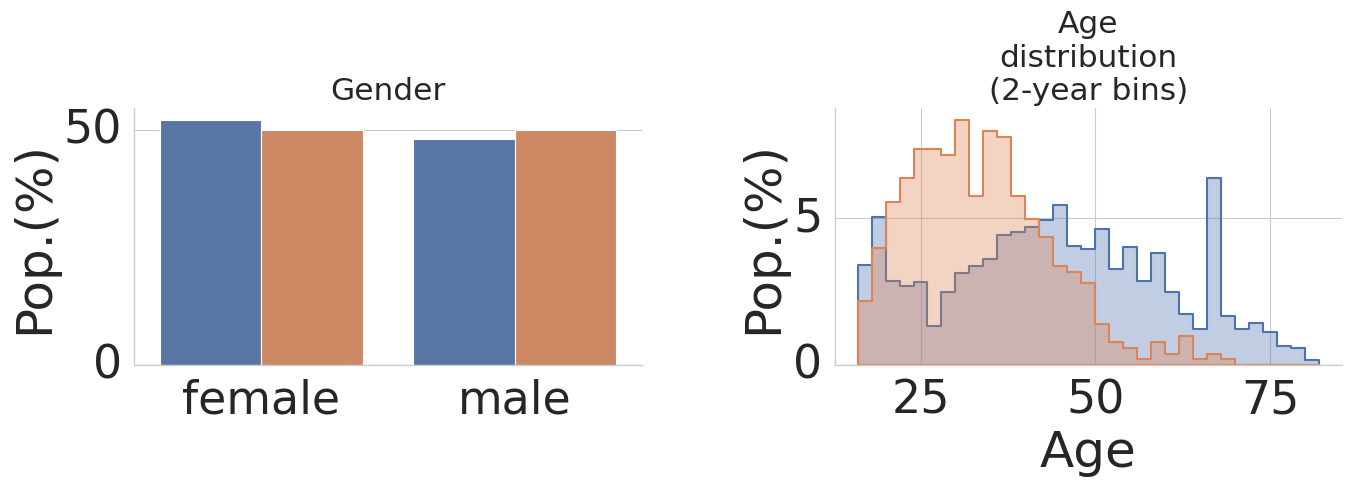

<Figure size 600x60 with 0 Axes>

In [5]:
fig, (ax_gender, ax_age_hist) = plt.subplots(1, 2, figsize=(14.4, 5.75))

handles, labels = _draw_bar_comparison(ax_gender, gender_cmp, "gender", horizontal=False)
ax_gender.set_title("Gender", fontsize=22.5)

for source in SOURCE_ORDER:
    sns.histplot(
        data=age_long[age_long["source"] == source],
        x="age", weights="weight", bins=age_bins, stat="percent", common_norm=False,
        element="step", fill=True, alpha=0.35, linewidth=1.5,
        color=PALETTE[source], label=source, ax=ax_age_hist,
    )
ax_age_hist.set_xlabel("Age")
ax_age_hist.set_ylabel("Pop.(%)")
ax_age_hist.set_title("Age distribution (2-year bins)", fontsize=22.5)
_style_axis_labels_and_ticks(ax_age_hist)
sns.despine(ax=ax_age_hist)

fig.tight_layout()
fig.savefig(FIG_DIR_500 / "age_gender_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

gender_cmp.to_csv(FIG_DIR_500 / "age_gender_comparison_gender.csv", index=False)
age_cmp.to_csv(FIG_DIR_500 / "age_gender_comparison_age_group.csv", index=False)

# Standalone single-row legend, saved separately for reuse in LaTeX (every
# figure in this notebook hides its own legend).
fig_legend = plt.figure(figsize=(6.0, 0.6))
fig_legend.legend(handles, [_wrap_every_two_words(label) for label in labels], loc="center", ncol=len(handles), frameon=False)
fig_legend.savefig(FIG_DIR_500 / "age_gender_comparison_legend.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig_legend)


## Education

The survey's `DIPLOMA` has 6 non-missing levels; CityBehavEx generates 5 (`EDUCATION_LEVELS` in
`citybehavex/profiles/agents.py`). The only merge needed is folding the survey's separate
"Brevet" (lower secondary) and "Baccalauréat" (upper secondary) levels into the generation's
single "secondary or less" bucket.

~15.8% of respondents have a missing `DIPLOMA` (adults, mean age ~47 — not a child-coding
artifact); those rows are dropped from this comparison rather than guessed into a bucket.


Dropping 526 respondents with missing DIPLOMA (15.8%).


,education,GParis survey (weighted),CityBehavEx generation,abs_pct_point_gap
0,no diploma,2.375741,11.706349,9.330608
1,secondary or less,46.255665,26.190476,20.065189
2,vocational or technical,13.351065,23.015873,9.664808
3,bachelor,15.206881,19.642857,4.435976
4,master or above,22.810648,19.444444,3.366203


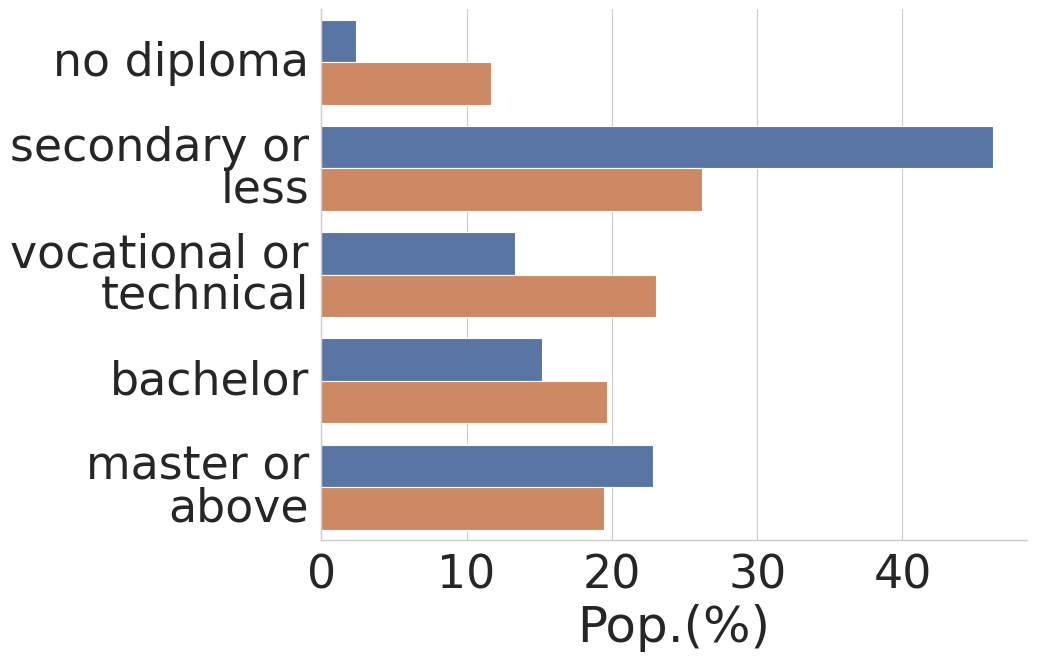

In [6]:
EDUCATION_MAP = {
    "No diploma": "no diploma",
    "Lower secondary certificate (Brevet) or equivalent": "secondary or less",
    "Upper secondary diploma (Baccalauréat) or equivalent": "secondary or less",
    "Vocational certificate (CAP, BEP) or equivalent": "vocational or technical",
    "3–4-year higher education degree: Licence, Professional Licence, Master 1, or equivalent": "bachelor",
    "5-year-and-above higher education degree: Master's 2, DEA, DESS, Grande École Diploma, Doctorate, etc.": "master or above",
}
survey["education_h"] = survey["DIPLOMA"].map(EDUCATION_MAP)
unmapped = sorted(survey.loc[survey["DIPLOMA"].notna() & survey["education_h"].isna(), "DIPLOMA"].unique())
assert not unmapped, f"Unmapped DIPLOMA values: {unmapped}"
print(f"Dropping {survey['DIPLOMA'].isna().sum():,} respondents with missing DIPLOMA ({survey['DIPLOMA'].isna().mean():.1%}).")

EDUCATION_CATEGORIES = ["no diploma", "secondary or less", "vocational or technical", "bachelor", "master or above"]
education_cmp = comparison_frame(survey, "education_h", generated, "education", EDUCATION_CATEGORIES, "education")
display(education_cmp)
plot_comparison(education_cmp, "education", "education_comparison", horizontal=True, tick_label_scale=1.0)
summary_rows.append({"variable": "education", "total_variation_distance_pct": total_variation_distance(education_cmp)})


## Household composition

`TYPE_HOUSE` has 8 categories vs. the generation's 7 `HOUSEHOLD_TYPES`; the survey's two
"unrelated housemates" variants ("Not related to other household members" and "In a shared
apartment (flat-sharing)") both fold into the generation's single "shared housing" bucket.


,household,GParis survey (weighted),CityBehavEx generation,abs_pct_point_gap
0,living alone,13.902485,5.753968,8.148517
1,couple without children,22.844897,21.031746,1.813151
2,couple with children,37.526186,30.952381,6.573805
3,single parent,9.281275,8.928571,0.352704
4,living with parents,13.427444,4.960317,8.467126
5,living with another family member,1.525387,10.119048,8.593660
6,shared housing,1.492325,18.253968,16.761643


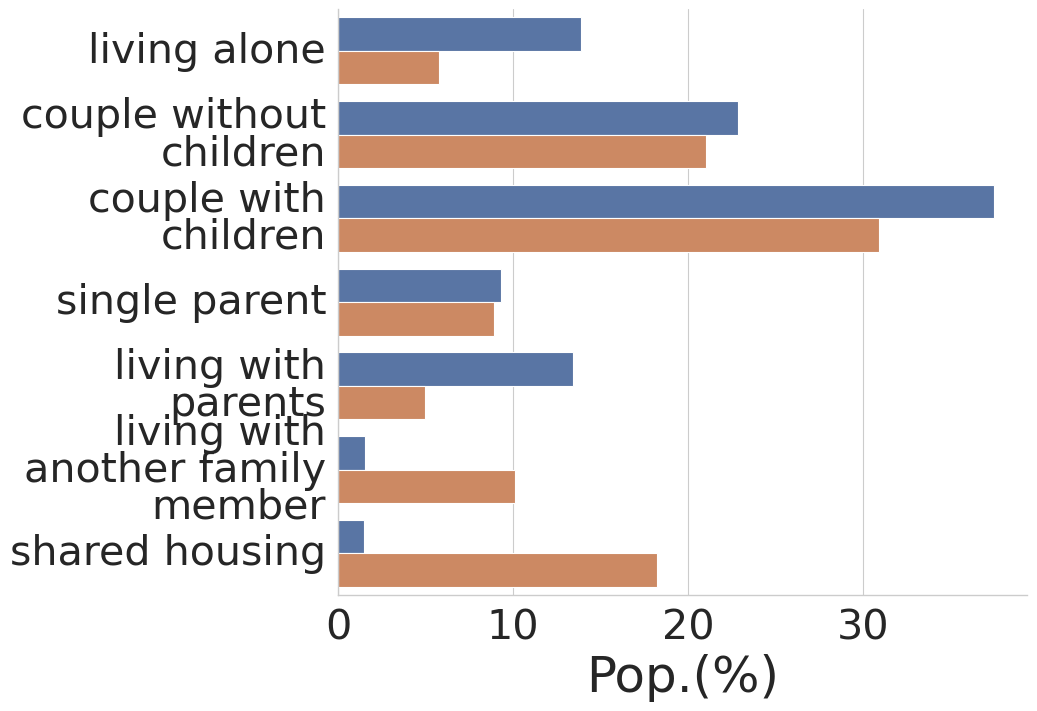

In [7]:
HOUSEHOLD_MAP = {
    "Not related to other household members": "shared housing",
    "In a shared apartment (flat-sharing)": "shared housing",
    "In a couple with child(ren)": "couple with children",
    "In a couple without children": "couple without children",
    "Another family member in the household": "living with another family member",
    "Single parent (divorced / separated / widowed)": "single parent",
    "Living with one or both parents": "living with parents",
    "Living alone": "living alone",
}
survey["household_h"] = survey["TYPE_HOUSE"].map(HOUSEHOLD_MAP)
unmapped = sorted(survey.loc[survey["TYPE_HOUSE"].notna() & survey["household_h"].isna(), "TYPE_HOUSE"].unique())
assert not unmapped, f"Unmapped TYPE_HOUSE values: {unmapped}"
assert survey["household_h"].notna().all(), "Unexpected missing TYPE_HOUSE."

HOUSEHOLD_CATEGORIES = [
    "living alone", "couple without children", "couple with children", "single parent",
    "living with parents", "living with another family member", "shared housing",
]
household_cmp = comparison_frame(survey, "household_h", generated, "household", HOUSEHOLD_CATEGORIES, "household")
display(household_cmp)
plot_comparison(household_cmp, "household", "household_comparison", horizontal=True, figsize=(11.25, 8.0), tick_label_scale=0.9)
summary_rows.append({"variable": "household", "total_variation_distance_pct": total_variation_distance(household_cmp)})


## Car and bike ownership

Direct threshold mapping: `NB_CAR > 0` → `has_car`, `BIKE != "0"` → `has_bike`.


,has_car,GParis survey (weighted),CityBehavEx generation,abs_pct_point_gap
0,True,73.377774,51.785714,21.59206
1,False,26.622226,48.214286,21.59206


,has_bike,GParis survey (weighted),CityBehavEx generation,abs_pct_point_gap
0,True,54.484822,56.150794,1.665972
1,False,45.515178,43.849206,1.665972


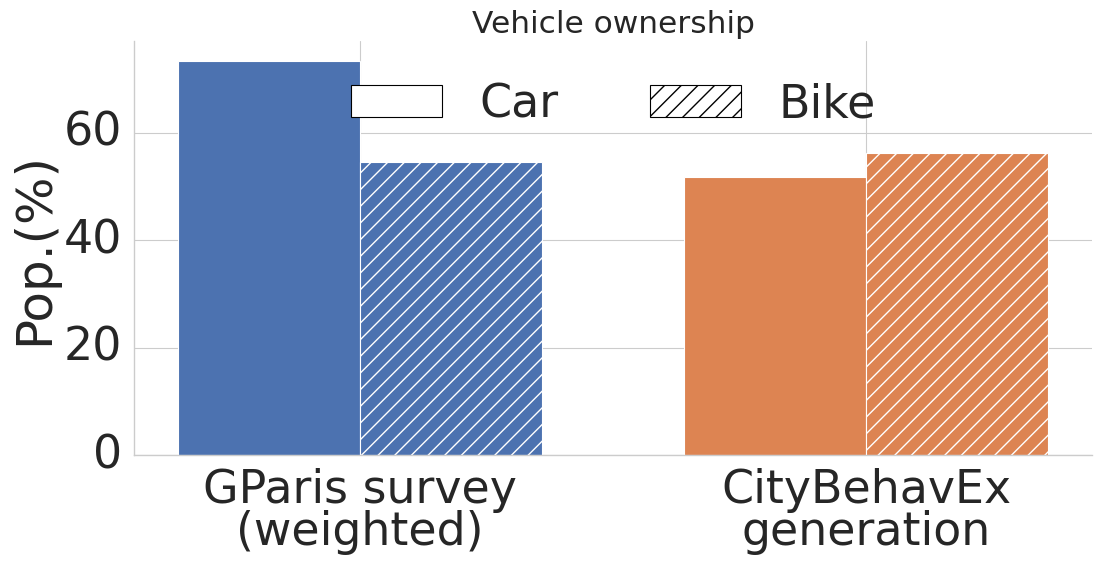

In [8]:
survey["has_car_h"] = survey["NB_CAR"] > 0
survey["has_bike_h"] = survey["BIKE"].astype(str) != "0"

BOOL_CATEGORIES = [True, False]

car_cmp = comparison_frame(survey, "has_car_h", generated, "has_car", BOOL_CATEGORIES, "has_car")
display(car_cmp)
summary_rows.append({"variable": "has_car", "total_variation_distance_pct": total_variation_distance(car_cmp)})

bike_cmp = comparison_frame(survey, "has_bike_h", generated, "has_bike", BOOL_CATEGORIES, "has_bike")
display(bike_cmp)
summary_rows.append({"variable": "has_bike", "total_variation_distance_pct": total_variation_distance(bike_cmp)})

plot_ownership_panels(car_cmp, bike_cmp, "ownership_comparison")


## Occupation / labor-force status

This is the one axis where the two sources are structurally different, not just differently
labeled:

- The survey's `PRO_CAT` (per `codebooks/NetMob25 Dataset Slides.pdf`) covers the **whole**
  population: 5 working categories (1 craftsman/tradesman/business owner, 2 executive/senior
  intellectual profession, 3 intermediate profession, 4 employee, 5 worker) **plus** 3
  not-currently-working categories (6 retired/pre-retired, 7 student/high-school student, 8
  unemployed/inactive).
- CityBehavEx's generated `job` (`ILOSTAT_JOBS` in `citybehavex/profiles/agents.py`) is an
  ISCO-08-style major-group taxonomy assigned to **every** agent — there is no "not working"
  state, so 100% of generated agents fall in the "working" bucket by construction.

So the comparison has two parts: first, how much of the real population isn't in the "working"
bucket at all (a gap CityBehavEx's profile generator has no way to close today); second,
*among* the working population, how the two occupation taxonomies compare once collapsed onto
the same 5-bucket scale.

The ISCO → PCS-5 collapse below is an approximate crosswalk (documented, not derived from an
official table) — ISCO "managers" and "professionals" both fold into the survey's single
"executive and senior intellectual profession" bucket, "clerical support" and "service or
sales" both fold into "employee", and "agricultural", "machine operator" and "elementary" all
fold into "worker".


In [9]:
LABOR_STATUS_MAP = {
    1: "working", 2: "working", 3: "working", 4: "working", 5: "working",
    6: "retired / pre-retired", 7: "student", 8: "unemployed / inactive",
}
survey["labor_status"] = survey["PRO_CAT"].map(LABOR_STATUS_MAP)
assert survey["labor_status"].notna().all(), "Unmapped PRO_CAT value found."

LABOR_STATUS_CATEGORIES = ["working", "retired / pre-retired", "student", "unemployed / inactive"]
generated["labor_status"] = "working"  # every generated agent has a job

labor_cmp = comparison_frame(survey, "labor_status", generated, "labor_status", LABOR_STATUS_CATEGORIES, "labor_status")
display(labor_cmp)
summary_rows.append({"variable": "labor_status", "total_variation_distance_pct": total_variation_distance(labor_cmp)})


,labor_status,GParis survey (weighted),CityBehavEx generation,abs_pct_point_gap
0,working,67.053666,100.0,32.946334
1,retired / pre-retired,14.719275,0.0,14.719275
2,student,13.583234,0.0,13.583234
3,unemployed / inactive,4.643824,0.0,4.643824


Working survey respondents: 2,346 of 3,337 (67.1% of weighted population).


,job,GParis survey (weighted),CityBehavEx generation,abs_pct_point_gap
0,craftsman / tradesman / business owner,5.268261,7.142857,1.874596
1,executive / senior intellectual profession,29.292968,38.888889,9.595921
2,intermediate profession,25.627237,11.904762,13.722475
3,employee,30.433413,26.388889,4.044524
4,worker,9.378122,15.674603,6.296482


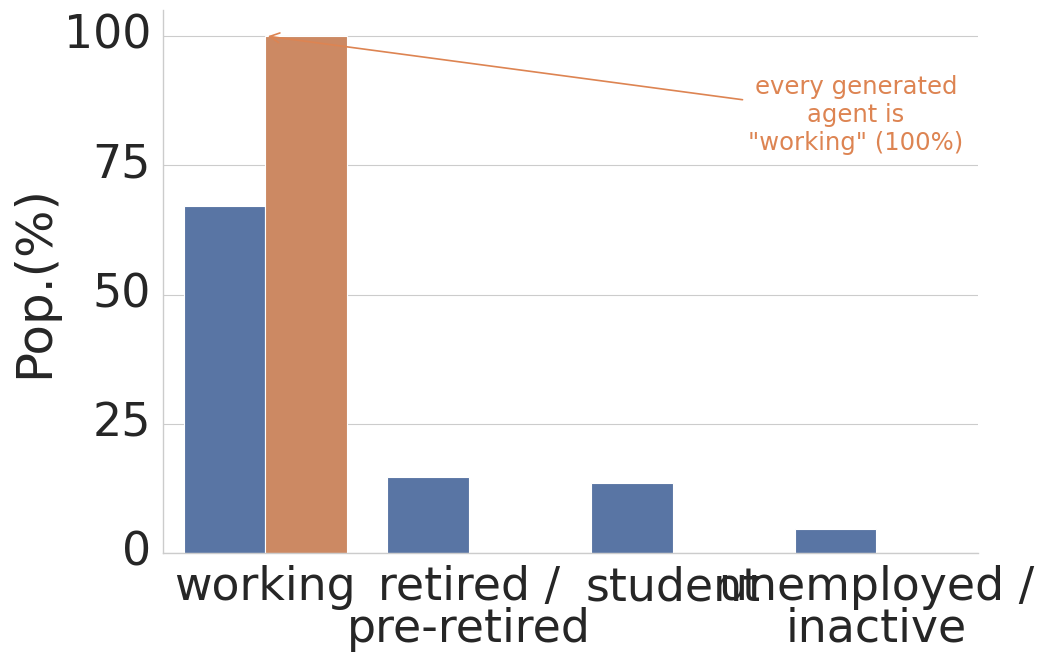

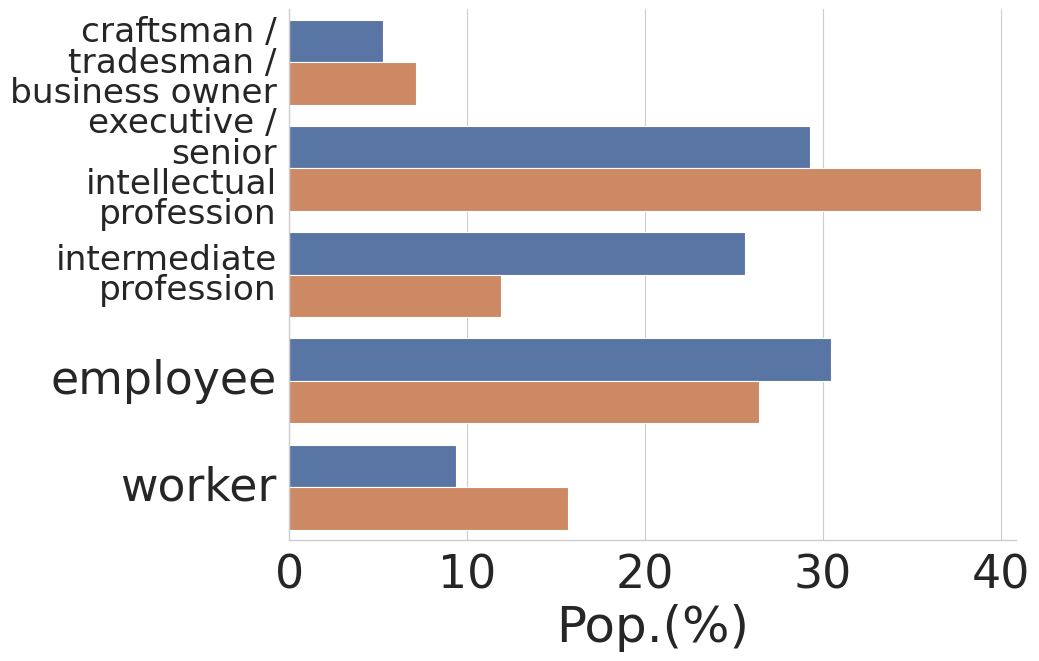

In [10]:
PRO_CAT_LABELS = {
    1: "craftsman / tradesman / business owner",
    2: "executive / senior intellectual profession",
    3: "intermediate profession",
    4: "employee",
    5: "worker",
}
survey["job_h"] = survey["PRO_CAT"].map(PRO_CAT_LABELS)  # NaN for codes 6-8 (not working)

ISCO_TO_PCS5 = {
    "manager": "executive / senior intellectual profession",
    "professional": "executive / senior intellectual profession",
    "technician or associate professional": "intermediate profession",
    "clerical support worker": "employee",
    "service or sales worker": "employee",
    "craft or trades worker": "craftsman / tradesman / business owner",
    "agricultural or fishery worker": "worker",
    "machine operator or assembler": "worker",
    "elementary worker": "worker",
}
generated["job_h"] = generated["job"].map(ISCO_TO_PCS5)
assert generated["job_h"].notna().all(), "Unmapped generated job label found."

working_survey = survey[survey["labor_status"] == "working"]
print(f"Working survey respondents: {len(working_survey):,} of {len(survey):,} "
      f"({working_survey[WEIGHT_COL].sum() / survey[WEIGHT_COL].sum():.1%} of weighted population).")

JOB_CATEGORIES = [
    "craftsman / tradesman / business owner", "executive / senior intellectual profession",
    "intermediate profession", "employee", "worker",
]
job_cmp = comparison_frame(working_survey, "job_h", generated, "job_h", JOB_CATEGORIES, "job")
display(job_cmp)
summary_rows.append({"variable": "occupation_among_working", "total_variation_distance_pct": total_variation_distance(job_cmp)})

fig, ax = plt.subplots(figsize=FIGSIZE)
_draw_bar_comparison(ax, labor_cmp, "labor_status", horizontal=False)
ax.annotate(
    'every generated\nagent is\n"working" (100%)',
    xy=(0, 100), xytext=(0.85, 78), textcoords=("axes fraction", "data"),
    ha="center", fontsize=17.5, color=PALETTE[GEN_LABEL],
    arrowprops=dict(arrowstyle="->", color=PALETTE[GEN_LABEL], lw=1.2),
)
fig.tight_layout()
fig.savefig(FIG_DIR_500 / "labor_status_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()
labor_cmp.to_csv(FIG_DIR_500 / "labor_status_comparison.csv", index=False)

plot_comparison(job_cmp, "job", "occupation_comparison", horizontal=True, tick_label_scale=1.0, multiline_tick_scale=0.75)


## Summary

Total variation distance (TVD) per variable: `0.5 * sum(|real % - generated %|)` across
categories, on a 0-100 scale where 0 = identical distributions and 100 = fully disjoint. This
mirrors the absolute-gap summary style used in `04_mtus_comparision.ipynb`.


,variable,total_variation_distance_pct
0,age_group,33.401149
1,labor_status,32.946334
2,household,25.355304
3,education,23.431393
4,has_car,21.592060
5,occupation_among_working,17.766998
6,gender,2.058332
7,has_bike,1.665972


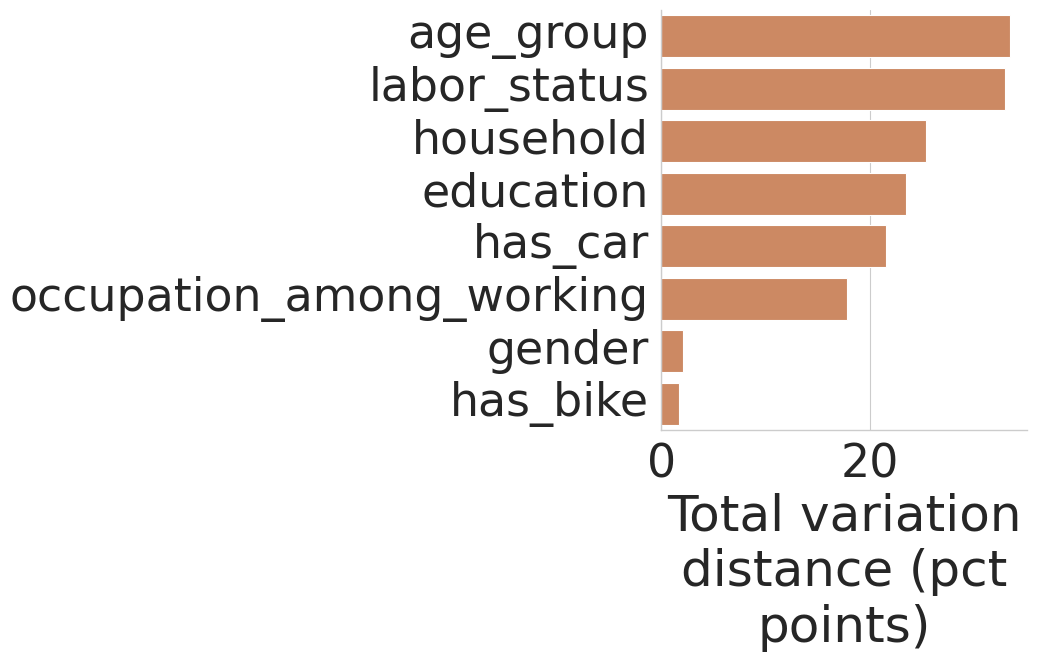

In [11]:
summary = pd.DataFrame(summary_rows).sort_values("total_variation_distance_pct", ascending=False).reset_index(drop=True)
display(summary)
summary.to_csv(FIG_DIR_500 / "tvd_summary.csv", index=False)

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(
    data=summary, y="variable", x="total_variation_distance_pct",
    order=summary["variable"], color=PALETTE[GEN_LABEL], ax=ax,
)
ax.set_xlabel("Total variation distance (pct points)")
ax.set_ylabel("")
_style_axis_labels_and_ticks(ax)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIG_DIR_500 / "tvd_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()


## Calibrating a 10,000-agent generation

The comparison above is against the 504-agent `idf_home_work_from_gparis` generation, whose
config (`llm_override: true`) calibrates its multinomial weights via an LLM reading a one-line
city description — not from the survey's actual weighted distributions. This section instead:

1. Fits `AgentProfilesConfig`'s multinomial/Beta weights directly to this notebook's own
   weighted survey shares (computed above), producing a **gparis-calibrated config**.
2. Generates **10,000 agents** from CityBehavEx's plain **default config** (out-of-the-box
   weights, no calibration, no alignment) and from the **gparis-calibrated config**, the latter
   passed through the same vehicle-ownership **aligner** (`rerank` cross-encoder at
   `ownership_alignment_base_url`, per `configs/idf_home_work_from_gparis_simulation.yaml`) the
   real pipeline uses, so car/bike ownership follows from each profile's narrative rather than
   flat Bernoulli draws.
3. Re-runs every demographic comparison above as a 3-way: real survey vs. default-config
   generation vs. gparis-calibrated+aligned generation.

Demographic generation here bypasses `configs/idf_home_work_from_gparis_simulation.yaml`'s own
`profiles.output`/cache paths entirely (kept `None`, or redirected under this notebook's
`outputs/`) so nothing here overwrites that pipeline's real artifacts. Embeddings are disabled
(`embedding.enabled=False`) — the ownership aligner still runs, just without embedding-based
profile clustering, which only trades a small amount of extra aligner calls for one less moving
part (no embedding server needed).


In [12]:
from citybehavex.config import load_config
from citybehavex.profiles import AgentProfilesConfig, EDUCATION_LEVELS, HOUSEHOLD_TYPES, ILOSTAT_JOBS, generate_profiles, profiles_to_frame
from citybehavex.simulation.profile_pipeline import _apply_vehicle_ownership_alignment

# --- Education / household: reuse the harmonized weighted survey shares already
# computed above, reordered into the exact category order AgentProfilesConfig expects.
adjusted_education_weights = (weighted_shares(survey, "education_h", EDUCATION_LEVELS, WEIGHT_COL) / 100).tolist()
adjusted_household_weights = (weighted_shares(survey, "household_h", HOUSEHOLD_TYPES, WEIGHT_COL) / 100).tolist()

# --- Car / bike ownership probabilities
adjusted_car_probability = float(weighted_shares(survey, "has_car_h", [True, False], WEIGHT_COL)[True] / 100)
adjusted_bike_probability = float(weighted_shares(survey, "has_bike_h", [True, False], WEIGHT_COL)[True] / 100)

# --- Age: method-of-moments Beta(a, b) fit to the weighted real age distribution,
# scaled to the survey's own [16, 80] range (CityBehavEx's default age bounds already match).
def fit_beta_scaled(values: pd.Series, weights: pd.Series, low: int, high: int) -> tuple[float, float]:
    scaled = np.clip((values.to_numpy(dtype=float) - low) / (high - low), 1e-6, 1 - 1e-6)
    w = weights.to_numpy(dtype=float)
    mean = np.average(scaled, weights=w)
    var = np.average((scaled - mean) ** 2, weights=w)
    common = mean * (1 - mean) / var - 1
    return float(mean * common), float((1 - mean) * common)

adjusted_age_beta_a, adjusted_age_beta_b = fit_beta_scaled(survey["AGE"], survey[WEIGHT_COL], 16, 80)

# --- Occupation: the working-population PCS-5 shares already computed in `job_cmp`,
# expanded onto CityBehavEx's 9-category ISCO-style scale. French PCS doesn't distinguish
# within these buckets, so each bucket's share is split evenly across its ISCO categories
# (a documented assumption, not derived) -- except agricultural work, set to zero since
# Greater Paris has essentially no farming employment (the survey has no separate
# "farmer" category at all; PRO_CAT 1 is craftsman/tradesman/business owner, not agriculture).
PCS5_TO_ISCO_SPLIT = {
    "craftsman / tradesman / business owner": {"craft or trades worker": 1.0},
    "executive / senior intellectual profession": {"manager": 0.5, "professional": 0.5},
    "intermediate profession": {"technician or associate professional": 1.0},
    "employee": {"clerical support worker": 0.5, "service or sales worker": 0.5},
    "worker": {"agricultural or fishery worker": 0.0, "machine operator or assembler": 0.5, "elementary worker": 0.5},
}
real_job_shares = weighted_shares(working_survey, "job_h", JOB_CATEGORIES, WEIGHT_COL) / 100
isco_weight = {job: 0.0 for job in ILOSTAT_JOBS}
for pcs5_bucket, share in real_job_shares.items():
    for isco_job, fraction in PCS5_TO_ISCO_SPLIT[pcs5_bucket].items():
        isco_weight[isco_job] += float(share) * fraction
adjusted_job_weights = [isco_weight[job] for job in ILOSTAT_JOBS]

print("education weights:", dict(zip(EDUCATION_LEVELS, np.round(adjusted_education_weights, 3))))
print("household weights:", dict(zip(HOUSEHOLD_TYPES, np.round(adjusted_household_weights, 3))))
print("job weights:      ", dict(zip(ILOSTAT_JOBS, np.round(adjusted_job_weights, 3))))
print(f"car_probability={adjusted_car_probability:.3f}, bike_probability={adjusted_bike_probability:.3f}")
print(f"age_beta_a={adjusted_age_beta_a:.3f}, age_beta_b={adjusted_age_beta_b:.3f} (defaults: 2.0, 5.0)")


education weights: {'no diploma': np.float64(0.024), 'secondary or less': np.float64(0.463), 'vocational or technical': np.float64(0.134), 'bachelor': np.float64(0.152), 'master or above': np.float64(0.228)}
household weights: {'shared housing': np.float64(0.015), 'couple with children': np.float64(0.375), 'couple without children': np.float64(0.228), 'living with another family member': np.float64(0.015), 'single parent': np.float64(0.093), 'living with parents': np.float64(0.134), 'living alone': np.float64(0.139)}
job weights:       {'manager': np.float64(0.146), 'professional': np.float64(0.146), 'technician or associate professional': np.float64(0.256), 'clerical support worker': np.float64(0.152), 'service or sales worker': np.float64(0.152), 'agricultural or fishery worker': np.float64(0.0), 'craft or trades worker': np.float64(0.053), 'machine operator or assembler': np.float64(0.047), 'elementary worker': np.float64(0.047)}
car_probability=0.734, bike_probability=0.545
age_bet

In [13]:
N_AGENTS_10K = 10_000
TESSELLATION_10K_PATH = PROJECT_ROOT / "data" / "idf" / "results" / "idf_gparis_tessellation_home_work_from_gparis.parquet"
GPARIS_CONFIG_PATH = PROJECT_ROOT / "configs" / "idf_home_work_from_gparis_simulation.yaml"

tessellation_10k = pd.read_parquet(TESSELLATION_10K_PATH)

base_config = load_config(str(GPARIS_CONFIG_PATH))
base_config = base_config.model_copy(update={
    "embedding": base_config.embedding.model_copy(update={"enabled": False}),
})

default_profiles_config = AgentProfilesConfig(
    enabled=True, output=str(FIG_DIR_10K / "notebook_default_10k_agent_profiles.parquet"),
)

adjusted_profiles_config = AgentProfilesConfig(
    enabled=True,
    output=str(FIG_DIR_10K / "notebook_adjusted_10k_agent_profiles.parquet"),
    llm_override=False,
    education_weights=adjusted_education_weights,
    household_weights=adjusted_household_weights,
    job_weights=adjusted_job_weights,
    car_probability=adjusted_car_probability,
    bike_probability=adjusted_bike_probability,
    age_beta_a=adjusted_age_beta_a,
    age_beta_b=adjusted_age_beta_b,
    ownership_alignment_backend=base_config.profiles.ownership_alignment_backend,
    ownership_alignment_base_url=base_config.profiles.ownership_alignment_base_url,
    ownership_alignment_model=base_config.profiles.ownership_alignment_model,
    ownership_alignment_batch_size=base_config.profiles.ownership_alignment_batch_size,
    ownership_alignment_concurrency=base_config.profiles.ownership_alignment_concurrency,
    ownership_alignment_cache_path=str(FIG_DIR_10K / "notebook_ownership_alignment_cache.npz"),
)

CACHE_DEFAULT_PATH = FIG_DIR_10K / "cache_default_frame.parquet"
CACHE_ADJUSTED_PATH = FIG_DIR_10K / "cache_adjusted_frame.parquet"
FORCE_REGENERATE = False  # set True, or delete the two cache_*.parquet files, to regenerate

if not FORCE_REGENERATE and CACHE_DEFAULT_PATH.exists() and CACHE_ADJUSTED_PATH.exists():
    default_frame = pd.read_parquet(CACHE_DEFAULT_PATH)
    adjusted_frame = pd.read_parquet(CACHE_ADJUSTED_PATH)
    print(
        f"Loaded cached 10k populations from {CACHE_DEFAULT_PATH.parent} "
        "(set FORCE_REGENERATE=True above, or delete those two files, to regenerate)."
    )
else:
    t0 = time.time()
    default_frame = profiles_to_frame(
        generate_profiles(N_AGENTS_10K, default_profiles_config, np.random.default_rng(42), tessellation_10k, relevance_column="relevance")
    )
    print(f"Default-config generation: {time.time() - t0:.1f}s for {N_AGENTS_10K:,} agents")

    t0 = time.time()
    adjusted_profiles = generate_profiles(
        N_AGENTS_10K, adjusted_profiles_config, np.random.default_rng(42), tessellation_10k, relevance_column="relevance"
    )
    print(f"Gparis-calibrated generation: {time.time() - t0:.1f}s for {N_AGENTS_10K:,} agents")

    adjusted_config_full = base_config.model_copy(update={"profiles": adjusted_profiles_config})
    t0 = time.time()
    adjusted_profiles = _apply_vehicle_ownership_alignment(adjusted_profiles, adjusted_config_full)
    adjusted_frame = profiles_to_frame(adjusted_profiles)
    print(f"Vehicle ownership alignment: {time.time() - t0:.1f}s for {N_AGENTS_10K:,} agents")
    print(f"Adjusted car ownership mean={adjusted_frame['has_car'].mean():.3f}, bike mean={adjusted_frame['has_bike'].mean():.3f} "
          f"(vs. Bernoulli draw means {adjusted_car_probability:.3f}/{adjusted_bike_probability:.3f})")

    default_frame.to_parquet(CACHE_DEFAULT_PATH, index=False)
    adjusted_frame.to_parquet(CACHE_ADJUSTED_PATH, index=False)


Loaded cached 10k populations from /home/gustavo/citybehavex/notebooks/00_ile_de_france_exploration/outputs/10k (set FORCE_REGENERATE=True above, or delete those two files, to regenerate).


In [14]:
for frame in (default_frame, adjusted_frame):
    frame["job_h"] = frame["job"].map(ISCO_TO_PCS5)
    frame["labor_status"] = "working"  # every generated agent has a job, by construction
    frame["age_group"] = pd.cut(frame["age"], bins=AGE_BINS, labels=AGE_LABELS, right=False)
assert default_frame["job_h"].notna().all() and adjusted_frame["job_h"].notna().all()

DEFAULT_LABEL = "CityBehavEx: default"
ADJUSTED_LABEL = "CityBehavEx: calibrated"
MULTI_SOURCE_ORDER = [REAL_LABEL, DEFAULT_LABEL, ADJUSTED_LABEL]
MULTI_PALETTE = {REAL_LABEL: PALETTE[REAL_LABEL], DEFAULT_LABEL: PALETTE[GEN_LABEL], ADJUSTED_LABEL: "#55A868"}

def tvd_between(comparison: pd.DataFrame, col_a: str, col_b: str) -> float:
    return float((comparison[col_a] - comparison[col_b]).abs().sum() / 2)

summary_rows_10k = []

def record_10k_tvd(variable: str, comparison: pd.DataFrame) -> None:
    summary_rows_10k.append({
        "variable": variable,
        "vs_default_tvd": tvd_between(comparison, REAL_LABEL, DEFAULT_LABEL),
        "vs_adjusted_tvd": tvd_between(comparison, REAL_LABEL, ADJUSTED_LABEL),
    })

# Standalone single-row legend (3 colored boxes + labels, no axes) for reuse in
# LaTeX -- every 10k figure below hides its own legend.
from matplotlib.patches import Patch
legend_handles_10k = [Patch(facecolor=MULTI_PALETTE[s], label=s) for s in MULTI_SOURCE_ORDER]
fig_legend = plt.figure(figsize=(9.0, 0.6))
fig_legend.legend(handles=legend_handles_10k, labels=[_wrap_every_two_words(label) for label in MULTI_SOURCE_ORDER], loc="center", ncol=len(MULTI_SOURCE_ORDER), frameon=False)
fig_legend.savefig(FIG_DIR_10K / "legend.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig_legend)


<Figure size 900x60 with 0 Axes>

### Age and gender (10k)

,gender,GParis survey (weighted),CityBehavEx: default,CityBehavEx: calibrated
0,female,52.058332,49.89,49.89
1,male,47.941668,50.11,50.11


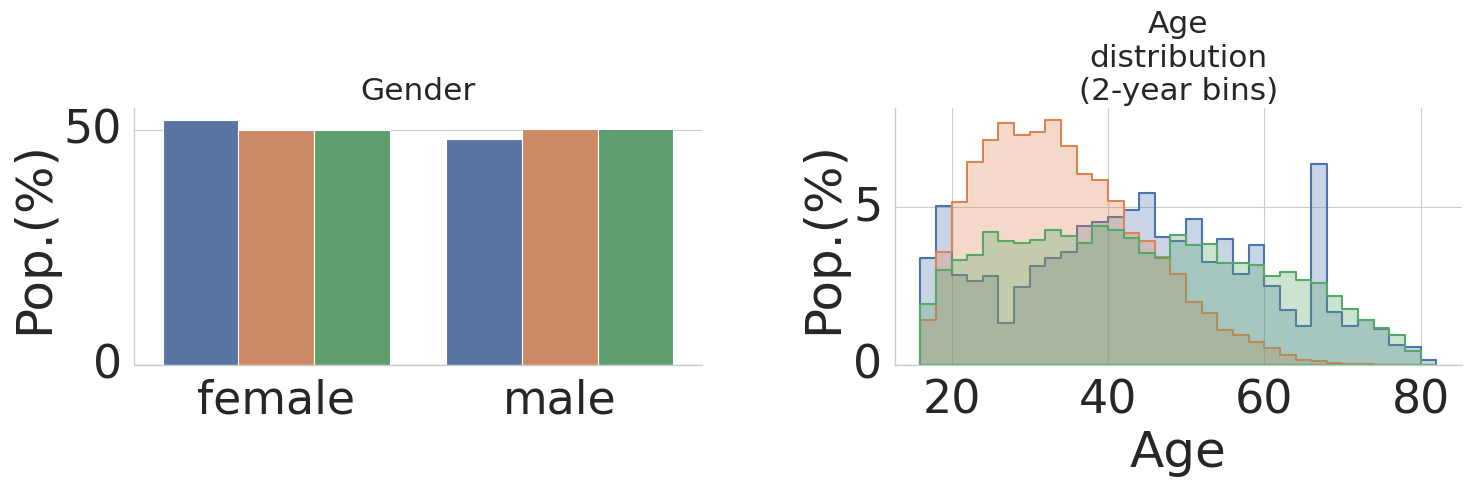

In [15]:
gender_cmp_10k = comparison_frame_multi(
    [
        (REAL_LABEL, survey, "gender_h", WEIGHT_COL),
        (DEFAULT_LABEL, default_frame, "gender", None),
        (ADJUSTED_LABEL, adjusted_frame, "gender", None),
    ],
    GENDER_CATEGORIES, "gender",
)
display(gender_cmp_10k)
record_10k_tvd("gender", gender_cmp_10k)

age_group_cmp_10k = comparison_frame_multi(
    [
        (REAL_LABEL, survey, "age_group", WEIGHT_COL),
        (DEFAULT_LABEL, default_frame, "age_group", None),
        (ADJUSTED_LABEL, adjusted_frame, "age_group", None),
    ],
    AGE_LABELS, "age_group",
)
record_10k_tvd("age_group", age_group_cmp_10k)

age_long_10k = pd.concat(
    [
        pd.DataFrame({"age": survey["AGE"], "weight": survey[WEIGHT_COL], "source": REAL_LABEL}),
        pd.DataFrame({"age": default_frame["age"], "weight": 1.0, "source": DEFAULT_LABEL}),
        pd.DataFrame({"age": adjusted_frame["age"], "weight": 1.0, "source": ADJUSTED_LABEL}),
    ],
    ignore_index=True,
)

fig, (ax_gender_10k, ax_age_10k) = plt.subplots(1, 2, figsize=(15.6, 5.75))
_draw_bar_comparison(ax_gender_10k, gender_cmp_10k, "gender", source_order=MULTI_SOURCE_ORDER, palette=MULTI_PALETTE)
ax_gender_10k.set_title("Gender", fontsize=22.5)

for source in MULTI_SOURCE_ORDER:
    sns.histplot(
        data=age_long_10k[age_long_10k["source"] == source],
        x="age", weights="weight", bins=age_bins, stat="percent", common_norm=False,
        element="step", fill=True, alpha=0.3, linewidth=1.5,
        color=MULTI_PALETTE[source], label=source, ax=ax_age_10k,
    )
ax_age_10k.set_xlabel("Age")
ax_age_10k.set_ylabel("Pop.(%)")
ax_age_10k.set_title("Age distribution (2-year bins)", fontsize=22.5)
_style_axis_labels_and_ticks(ax_age_10k)
sns.despine(ax=ax_age_10k)

fig.tight_layout()
fig.savefig(FIG_DIR_10K / "age_gender_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

gender_cmp_10k.to_csv(FIG_DIR_10K / "age_gender_comparison_gender.csv", index=False)
age_group_cmp_10k.to_csv(FIG_DIR_10K / "age_gender_comparison_age_group.csv", index=False)


### Education (10k)

,education,GParis survey (weighted),CityBehavEx: default,CityBehavEx: calibrated
0,no diploma,2.375741,8.10,2.48
1,secondary or less,46.255665,32.18,46.17
2,vocational or technical,13.351065,23.51,13.88
3,bachelor,15.206881,25.95,15.18
4,master or above,22.810648,10.26,22.29


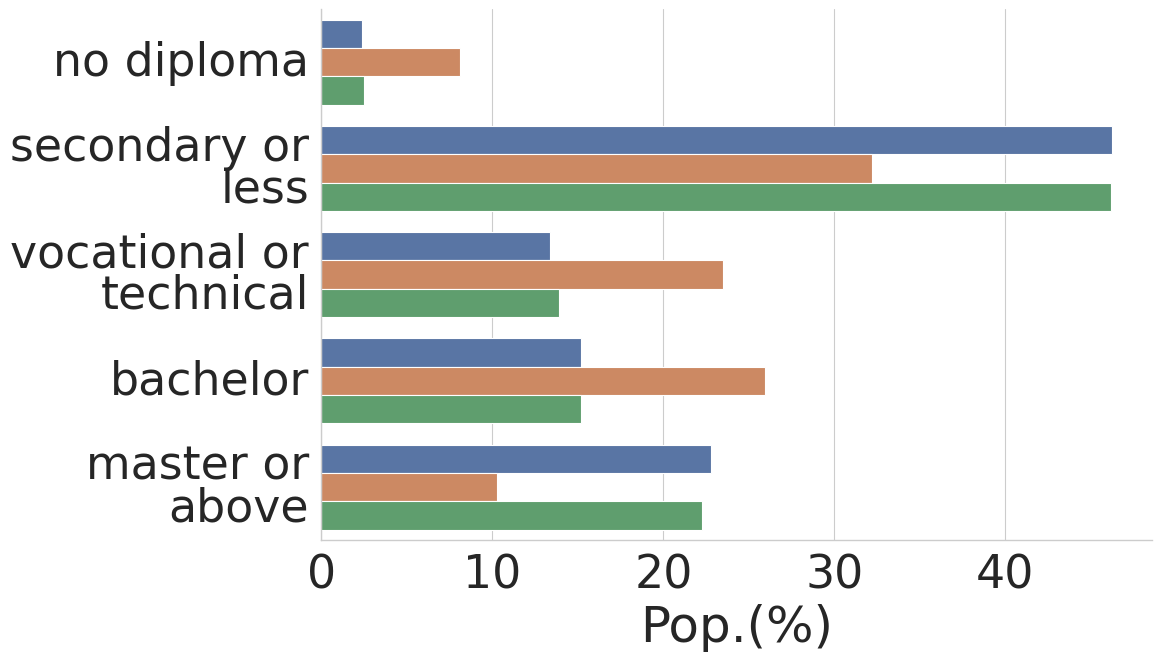

In [16]:
education_cmp_10k = comparison_frame_multi(
    [
        (REAL_LABEL, survey, "education_h", WEIGHT_COL),
        (DEFAULT_LABEL, default_frame, "education", None),
        (ADJUSTED_LABEL, adjusted_frame, "education", None),
    ],
    EDUCATION_CATEGORIES, "education",
)
display(education_cmp_10k)
plot_comparison(education_cmp_10k, "education", "education_comparison", horizontal=True, source_order=MULTI_SOURCE_ORDER, palette=MULTI_PALETTE, figsize=(12.5, 7.5), fig_dir=FIG_DIR_10K, tick_label_scale=1.0)
record_10k_tvd("education", education_cmp_10k)


### Household composition (10k)

,household,GParis survey (weighted),CityBehavEx: default,CityBehavEx: calibrated
0,living alone,13.902485,34.02,13.89
1,couple without children,22.844897,14.23,23.17
2,couple with children,37.526186,21.17,37.76
3,single parent,9.281275,6.03,8.75
4,living with parents,13.427444,12.03,13.40
5,living with another family member,1.525387,5.00,1.55
6,shared housing,1.492325,7.52,1.48


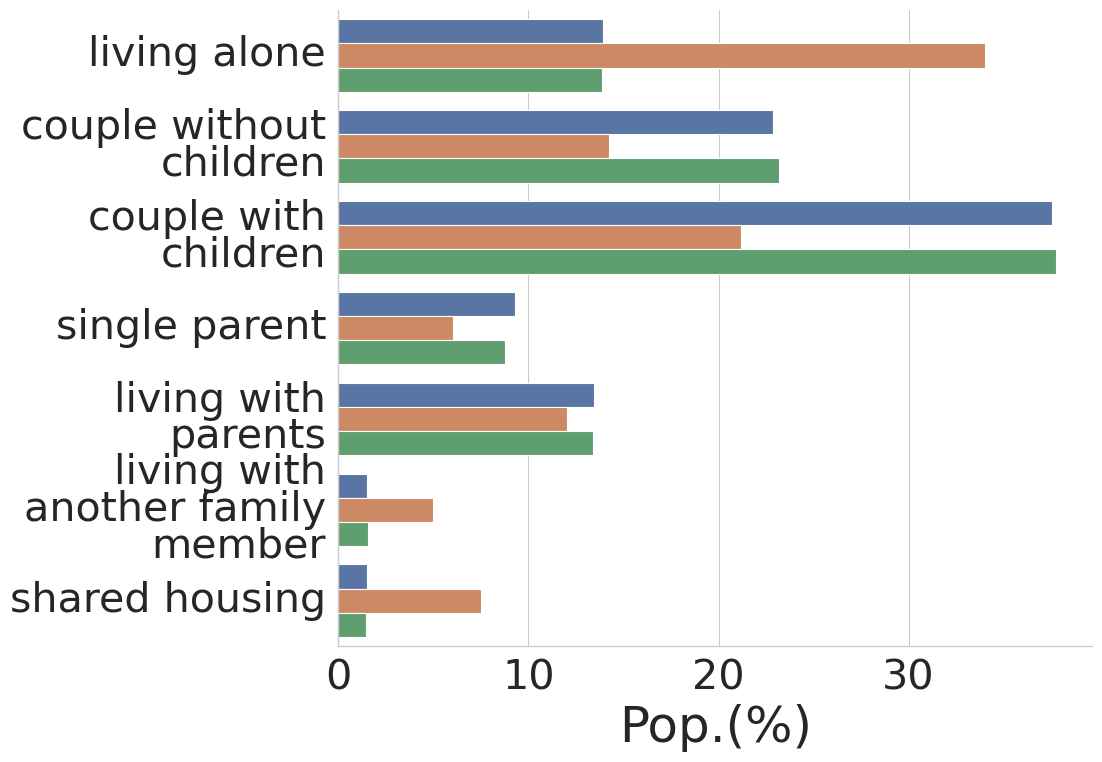

In [17]:
household_cmp_10k = comparison_frame_multi(
    [
        (REAL_LABEL, survey, "household_h", WEIGHT_COL),
        (DEFAULT_LABEL, default_frame, "household", None),
        (ADJUSTED_LABEL, adjusted_frame, "household", None),
    ],
    HOUSEHOLD_CATEGORIES, "household",
)
display(household_cmp_10k)
plot_comparison(
    household_cmp_10k, "household", "household_comparison", horizontal=True,
    source_order=MULTI_SOURCE_ORDER, palette=MULTI_PALETTE, figsize=(11.9, 8.5), fig_dir=FIG_DIR_10K,
    tick_label_scale=0.9,
)
record_10k_tvd("household", household_cmp_10k)


### Car and bike ownership (10k)

The default-config population draws `has_car`/`has_bike` as flat Bernoulli(p) coin flips — same
probability regardless of the rest of the profile. The gparis-calibrated population instead gets
its ownership from the aligner scoring each profile's narrative, so ownership can (in principle)
track age/job/household rather than being profile-independent.


,has_car,GParis survey (weighted),CityBehavEx: default,CityBehavEx: calibrated
0,True,73.377774,55.23,59.87
1,False,26.622226,44.77,40.13


,has_bike,GParis survey (weighted),CityBehavEx: default,CityBehavEx: calibrated
0,True,54.484822,35.34,68.34
1,False,45.515178,64.66,31.66


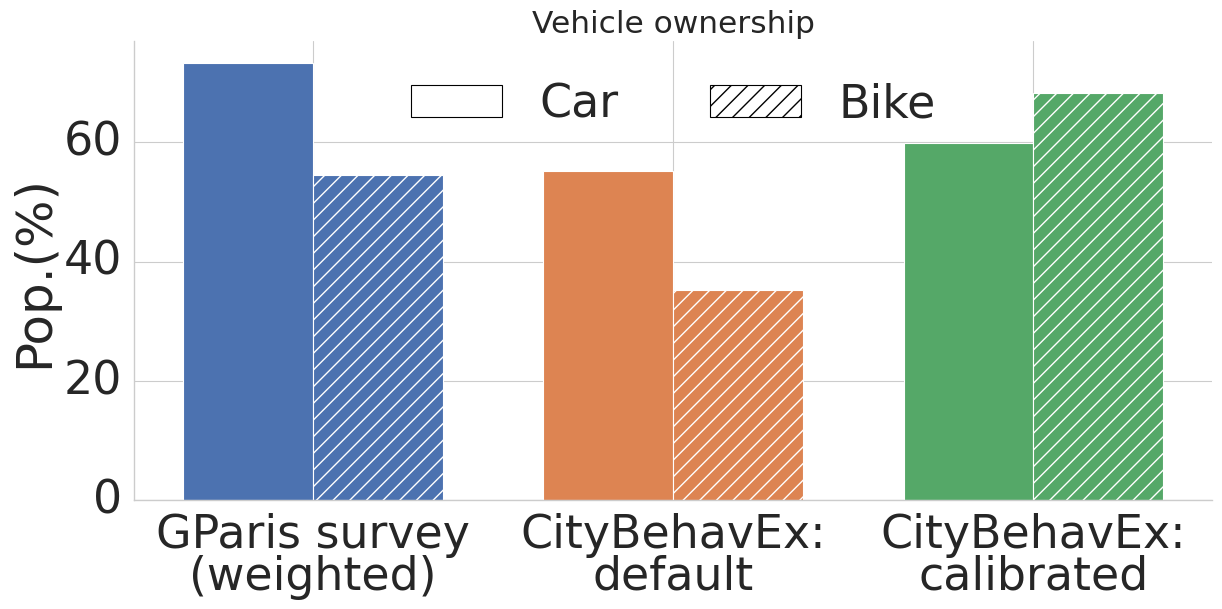

In [18]:
car_cmp_10k = comparison_frame_multi(
    [
        (REAL_LABEL, survey, "has_car_h", WEIGHT_COL),
        (DEFAULT_LABEL, default_frame, "has_car", None),
        (ADJUSTED_LABEL, adjusted_frame, "has_car", None),
    ],
    BOOL_CATEGORIES, "has_car",
)
record_10k_tvd("has_car", car_cmp_10k)

bike_cmp_10k = comparison_frame_multi(
    [
        (REAL_LABEL, survey, "has_bike_h", WEIGHT_COL),
        (DEFAULT_LABEL, default_frame, "has_bike", None),
        (ADJUSTED_LABEL, adjusted_frame, "has_bike", None),
    ],
    BOOL_CATEGORIES, "has_bike",
)
record_10k_tvd("has_bike", bike_cmp_10k)

display(car_cmp_10k)
display(bike_cmp_10k)
plot_ownership_panels(
    car_cmp_10k, bike_cmp_10k, "ownership_comparison",
    source_order=MULTI_SOURCE_ORDER, palette=MULTI_PALETTE, fig_dir=FIG_DIR_10K,
    figsize=(13.1, 7.75),
)


### Occupation / labor-force status (10k)

Same structural gap as the 504-agent comparison: both generated populations assign every agent a
job, so both read 100% "working" regardless of calibration — no multinomial-weight adjustment
can close this, since it isn't a weighting problem.


,labor_status,GParis survey (weighted),CityBehavEx: default,CityBehavEx: calibrated
0,working,67.053666,100.0,100.0
1,retired / pre-retired,14.719275,0.0,0.0
2,student,13.583234,0.0,0.0
3,unemployed / inactive,4.643824,0.0,0.0


,job,GParis survey (weighted),CityBehavEx: default,CityBehavEx: calibrated
0,craftsman / tradesman / business owner,5.268261,7.93,5.48
1,executive / senior intellectual profession,29.292968,32.00,29.23
2,intermediate profession,25.627237,16.08,25.87
3,employee,30.433413,29.73,30.19
4,worker,9.378122,14.26,9.23


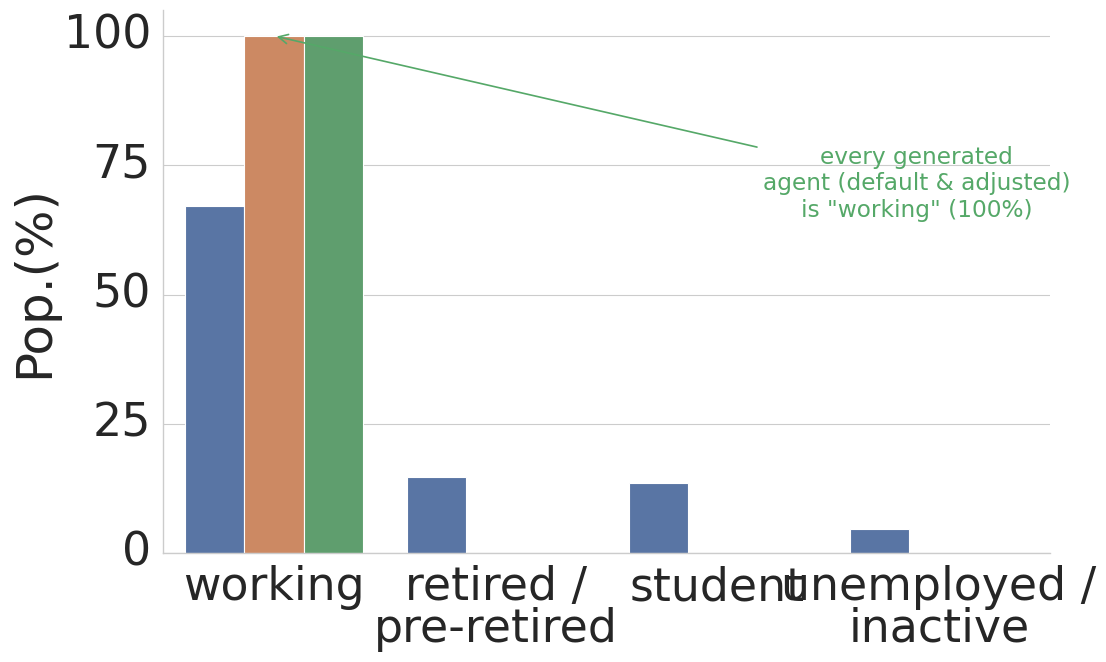

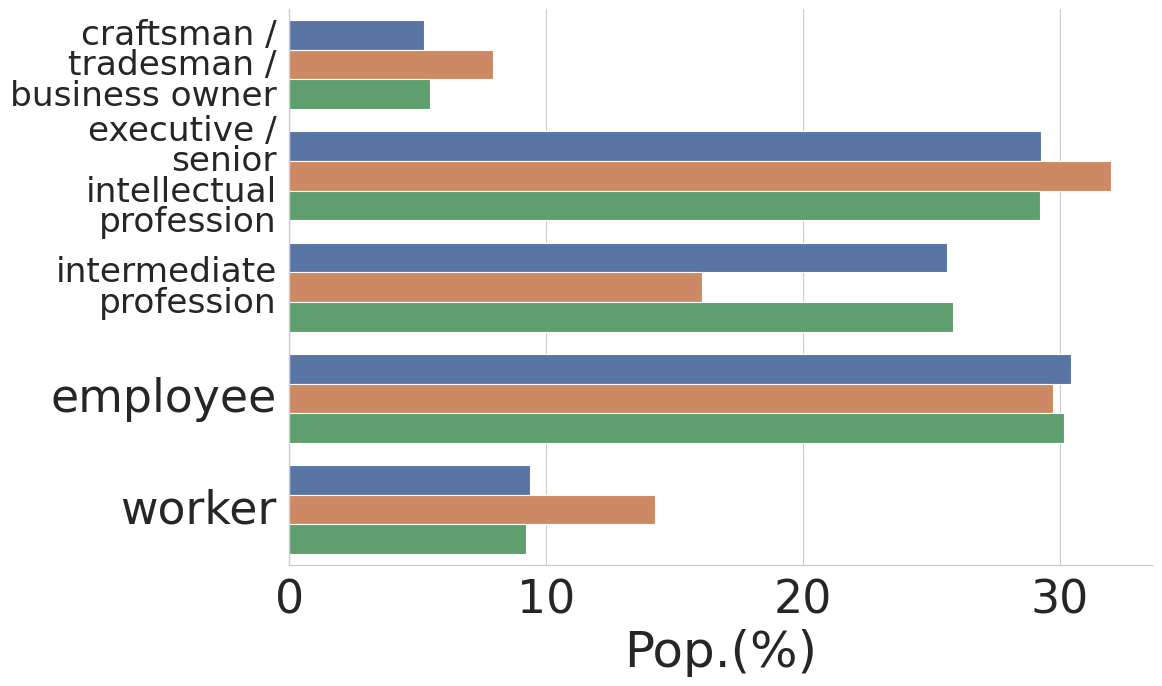

In [19]:
labor_cmp_10k = comparison_frame_multi(
    [
        (REAL_LABEL, survey, "labor_status", WEIGHT_COL),
        (DEFAULT_LABEL, default_frame, "labor_status", None),
        (ADJUSTED_LABEL, adjusted_frame, "labor_status", None),
    ],
    LABOR_STATUS_CATEGORIES, "labor_status",
)
record_10k_tvd("labor_status", labor_cmp_10k)

job_cmp_10k = comparison_frame_multi(
    [
        (REAL_LABEL, working_survey, "job_h", WEIGHT_COL),
        (DEFAULT_LABEL, default_frame, "job_h", None),
        (ADJUSTED_LABEL, adjusted_frame, "job_h", None),
    ],
    JOB_CATEGORIES, "job",
)
record_10k_tvd("occupation_among_working", job_cmp_10k)

display(labor_cmp_10k)
display(job_cmp_10k)

fig, ax = plt.subplots(figsize=(11.9, 7.5))
_draw_bar_comparison(ax, labor_cmp_10k, "labor_status", source_order=MULTI_SOURCE_ORDER, palette=MULTI_PALETTE)
ax.annotate(
    'every generated\nagent (default & adjusted)\nis "working" (100%)',
    xy=(0, 100), xytext=(0.85, 65), textcoords=("axes fraction", "data"),
    ha="center", fontsize=16.75, color=MULTI_PALETTE[ADJUSTED_LABEL],
    arrowprops=dict(arrowstyle="->", color=MULTI_PALETTE[ADJUSTED_LABEL], lw=1.2),
)
fig.tight_layout()
fig.savefig(FIG_DIR_10K / "labor_status_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()
labor_cmp_10k.to_csv(FIG_DIR_10K / "labor_status_comparison.csv", index=False)

plot_comparison(
    job_cmp_10k, "job", "occupation_comparison", horizontal=True,
    source_order=MULTI_SOURCE_ORDER, palette=MULTI_PALETTE, figsize=(12.5, 7.75), fig_dir=FIG_DIR_10K,
    tick_label_scale=1.0,
    multiline_tick_scale=0.75,
)


### Summary (10k)

Same total-variation-distance metric as the main summary, now split into "vs. default config"
and "vs. gparis-calibrated + aligner" so the effect of calibration is visible per variable.


,variable,vs_default_tvd,vs_adjusted_tvd
0,labor_status,32.946334,32.946334
1,age_group,31.265911,3.504125
2,household,29.619803,0.583529
3,education,26.626313,0.633195
4,has_bike,19.144822,13.855178
5,has_car,18.147774,13.507774
6,occupation_among_working,10.250649,0.454502
7,gender,2.168332,2.168332


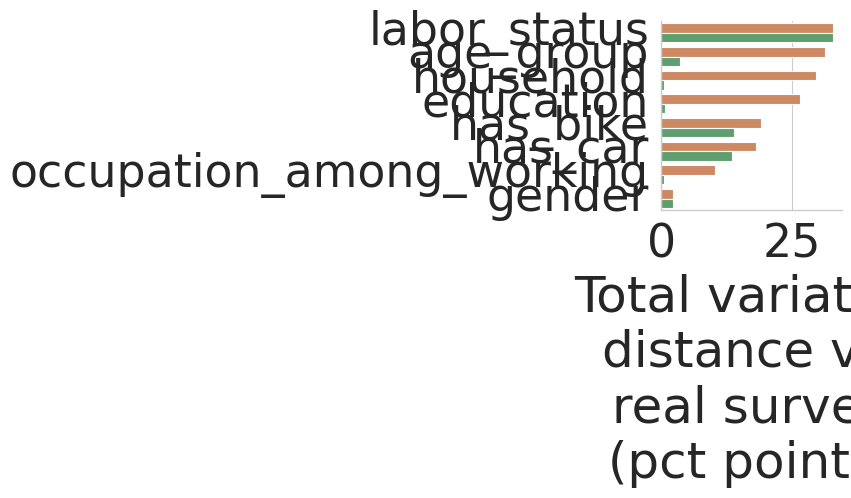

In [20]:
summary_10k = pd.DataFrame(summary_rows_10k).sort_values("vs_default_tvd", ascending=False).reset_index(drop=True)
display(summary_10k)
summary_10k.to_csv(FIG_DIR_10K / "tvd_summary.csv", index=False)

summary_10k_long = summary_10k.melt(
    id_vars=["variable"], value_vars=["vs_default_tvd", "vs_adjusted_tvd"],
    var_name="config", value_name="tvd",
)
summary_10k_long["config"] = summary_10k_long["config"].map({
    "vs_default_tvd": DEFAULT_LABEL, "vs_adjusted_tvd": ADJUSTED_LABEL,
})

fig, ax = plt.subplots(figsize=(9.4, 5.75))
sns.barplot(
    data=summary_10k_long, y="variable", x="tvd", hue="config",
    order=summary_10k["variable"], hue_order=[DEFAULT_LABEL, ADJUSTED_LABEL],
    palette={DEFAULT_LABEL: MULTI_PALETTE[DEFAULT_LABEL], ADJUSTED_LABEL: MULTI_PALETTE[ADJUSTED_LABEL]},
    ax=ax, legend=False,
)
ax.set_xlabel("Total variation distance vs. real survey (pct points)")
ax.set_ylabel("")
_style_axis_labels_and_ticks(ax)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIG_DIR_10K / "tvd_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()


### Caveats specific to the 10k calibration

- **Occupation weights are a best-effort split, not derived data**: the survey's PCS-5 shares
  (among working respondents) are divided evenly across each bucket's constituent ISCO
  categories (e.g. "executive" splits 50/50 into `manager`/`professional`) since the survey
  doesn't distinguish within these buckets — except agricultural work, pinned near zero since
  the survey has no farming category at all in this urban region.
- **Gender is not calibrated**: `generate_profiles` always draws gender as an unweighted 50/50
  coin flip (`agents.py`); there's no config knob for it, so both generated populations show
  ~50/50 regardless of the real ~52/48 split.
- **Ownership alignment ran without profile-embedding clustering** (`embedding.enabled=False`):
  every one of the 10,000 profiles was scored individually against the aligner rather than
  de-duplicated into similarity clusters first, trading some extra aligner calls for one fewer
  moving part (no embedding server dependency). Scores should be unaffected — clustering only
  reuses an identical score across near-duplicate narratives.
- **Default-config ownership is calibration- and alignment-free by design**: it's the same flat
  `car_probability`/`bike_probability` Bernoulli draw as the 504-agent generation, included here
  purely as the "no effort" baseline the calibrated + aligned population is measured against.


## Caveats

- **Generation scale**: the generated population is the 504 agents from the specific
  `idf_home_work_from_gparis` simulation run. There is no separately generated "full-scale"
  citybehavex population sized to match the survey's ~9.05M weighted target — comparisons are
  therefore on *relative* (percentage) distributions, not absolute counts.
- **Occupation mismatch is structural, not a labeling artifact**: ~33% of the
  weighted survey population is retired, a student, or otherwise not working, a state
  CityBehavEx's profile generator does not currently model (every agent gets a job).
- **Category crosswalks are approximate** where the two taxonomies don't line up 1:1
  (education's Brevet/Bac merge, household's two "unrelated housemates" variants merging, and
  especially the ISCO-to-PCS-5 occupation collapse) — see the markdown cell above each
  comparison for the exact mapping used.
- **Missing data**: ~15.8% of survey respondents have no recorded `DIPLOMA` and are excluded
  from the education comparison rather than imputed.
